In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Veri seti: Sıcak hava balonu eğitim uçuşlarından toplanmış gerçek uçuş verisi
# CSV dosyasını kendi ortamınıza göre aşağıdaki path'i güncelleyerek kullanabilirsiniz.
# Yerel ortam: df = pd.read_csv('enriched_train_flights.csv')
# Veri yükle
df = pd.read_csv("/content/drive/MyDrive/enriched_train_flights.csv")
df['time'] = pd.to_datetime(df['time'])  # Zamanı datetime yapalım

In [ ]:
import numpy as np

# Zamanı datetime yapalım (zaten yapmıştık ama yine dursun)
df['time'] = pd.to_datetime(df['time'])

# Yeni kolonlar listesi
df['delta_time'] = np.nan
df['horizontal_speed'] = np.nan
df['vertical_speed'] = np.nan
df['wind_u'] = np.nan
df['wind_v'] = np.nan

# Tüm uçuşlar için
for flight_id, flight_data in df.groupby('train_id'):
    flight_data = flight_data.sort_values('time').reset_index(drop=True)

    # delta_time (saniye cinsinden)
    delta_time = flight_data['time'].diff().dt.total_seconds()

    # yatay mesafe değişimi (sadece lat-lon farkı ile yaklaşık alınacak)
    lat_diff = np.radians(flight_data['latitude'].diff())
    lon_diff = np.radians(flight_data['longitude'].diff())
    earth_radius = 6371000  # metre

    a = np.sin(lat_diff / 2)**2 + np.cos(np.radians(flight_data['latitude'])).shift(1) * np.cos(np.radians(flight_data['latitude'])) * np.sin(lon_diff / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    horizontal_distance = earth_radius * c  # metre cinsinden

    horizontal_speed = horizontal_distance / delta_time  # m/s

    # vertical speed (altitude değişiminden)
    vertical_diff = flight_data['altitude'].diff()
    vertical_speed = vertical_diff / delta_time  # m/s

    # wind_u ve wind_v (rüzgar yönü ve hızı bileşenleri)
    wind_speed = flight_data['wind_speed_6am']
    wind_dir = flight_data['wind_dir_6am']

    wind_u = wind_speed * np.cos(np.radians(wind_dir))
    wind_v = wind_speed * np.sin(np.radians(wind_dir))

    # dataframe'e yazalım
    df.loc[flight_data.index, 'delta_time'] = delta_time
    df.loc[flight_data.index, 'horizontal_speed'] = horizontal_speed
    df.loc[flight_data.index, 'vertical_speed'] = vertical_speed
    df.loc[flight_data.index, 'wind_u'] = wind_u
    df.loc[flight_data.index, 'wind_v'] = wind_v

# İlk satırlar NaN çünkü diff yaptık. Onları ileri dolduralım
df.fillna(method='bfill', inplace=True)

print("✅ Feature engineering tamamlandı. Yeni kolonlar eklendi.")


✅ Feature engineering tamamlandı. Yeni kolonlar eklendi.


<ipython-input-65-e54415e2d095>:50: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)


In [ ]:
feature_cols = [
    'latitude',
    'longitude',
    'altitude',
    'temperature_6am',
    'pressure_6am',
    'wind_speed_6am',
    'wind_dir_6am',
    'delta_time',
    'horizontal_speed',
    'vertical_speed',
    'wind_u',
    'wind_v'
]


In [ ]:
# Parametre
NUM_STEPS = 10  # İlk 10 adımı kullanacağız

# X ve y listeleri
X_list = []
y_list = []

# Her uçuş için
for flight_id, flight_data in df.groupby('train_id'):
    flight_data = flight_data.sort_values('time')

    if len(flight_data) >= NUM_STEPS:  # Yeterli adımı olan uçuşlar
        # İlk 10 adımın feature değerleri
        first_steps = flight_data.iloc[:NUM_STEPS][feature_cols].values
        X_list.append(first_steps)

        # Çıkış: iniş noktası (son satırın latitude ve longitude'u)
        last_row = flight_data.iloc[-1]
        y_list.append([last_row['latitude'], last_row['longitude']])

# Numpy array'e çevir
X = np.array(X_list)
y = np.array(y_list)

# X içindeki tüm NaN değerleri sıfırla doldur
X = np.nan_to_num(X, nan=0.0)

# (y içinde NaN yoktu zaten, ona gerek yok)


print(f"✅ X shape: {X.shape}")  # (uçuş sayısı, 10, feature sayısı)
print(f"✅ y shape: {y.shape}")  # (uçuş sayısı, 2)


✅ X shape: (64, 10, 12)
✅ y shape: (64, 2)


In [ ]:
from sklearn.model_selection import train_test_split

# Veriyi train/validation olarak ayır
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✅ Eğitim seti boyutu: {X_train.shape}")
print(f"✅ Validation seti boyutu: {X_val.shape}")


✅ Eğitim seti boyutu: (51, 10, 12)
✅ Validation seti boyutu: (13, 10, 12)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Giriş verisi için scaler
scaler = StandardScaler()
X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
X_val_reshaped = X_val.reshape(-1, X_val.shape[-1])

scaler.fit(X_train_reshaped)

X_train_scaled = scaler.transform(X_train_reshaped).reshape(X_train.shape)
X_val_scaled = scaler.transform(X_val_reshaped).reshape(X_val.shape)

# Çıkış (y) verisi için scaler
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train)
y_val_scaled = y_scaler.transform(y_val)

In [ ]:
import tensorflow as tf

# Model
input_layer = tf.keras.Input(shape=(NUM_STEPS, len(feature_cols)))

lstm1 = tf.keras.layers.LSTM(256, return_sequences=True)(input_layer)
dropout1 = tf.keras.layers.Dropout(0.1)(lstm1)

lstm2 = tf.keras.layers.LSTM(128, return_sequences=False)(dropout1)
dropout2 = tf.keras.layers.Dropout(0.1)(lstm2)

dense = tf.keras.layers.Dense(64, activation='relu')(dropout2)
output_layer = tf.keras.layers.Dense(2)(dense)

model = tf.keras.Model(inputs=input_layer, outputs=output_layer)

# Derleme
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

# EarlyStopping ve ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/best_lstm_model.h5',
    monitor='val_loss',
    save_best_only=True
)

# Eğitim
history = model.fit(
    X_train_scaled, y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 5s 6s/step - loss: 1.3307 - mae: 0.8176

2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 948ms/step - loss: 1.1213 - mae: 0.7563 - val_loss: 1.4852 - val_mae: 0.8863
Epoch 2/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - loss: 1.0816 - mae: 0.7336

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - loss: 1.0030 - mae: 0.7072 - val_loss: 1.4429 - val_mae: 0.8673
Epoch 3/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.8366 - mae: 0.6702

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - loss: 0.8967 - mae: 0.6763 - val_loss: 1.4016 - val_mae: 0.8499
Epoch 4/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 1.2237 - mae: 0.7866

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - loss: 1.0049 - mae: 0.7058 - val_loss: 1.3781 - val_mae: 0.8392
Epoch 5/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.9486 - mae: 0.6891

...

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 187ms/step - loss: 0.7436 - mae: 0.5750 - val_loss: 1.2127 - val_mae: 0.7958
Epoch 14/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.6398 - mae: 0.5338

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - loss: 0.6507 - mae: 0.5398 - val_loss: 1.1477 - val_mae: 0.7750
Epoch 15/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.4105 - mae: 0.4640

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - loss: 0.5804 - mae: 0.5205 - val_loss: 1.0999 - val_mae: 0.7608
Epoch 16/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.4336 - mae: 0.4533

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - loss: 0.5678 - mae: 0.5092 - val_loss: 1.0711 - val_mae: 0.7508
Epoch 17/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 0.4529 - mae: 0.4575

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - loss: 0.5613 - mae: 0.5054 - val_loss: 1.0482 - val_mae: 0.7427
Epoch 18/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.6917 - mae: 0.5691 - val_loss: 1.0555 - val_mae: 0.7391
Epoch 19/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - loss: 0.6343 - mae: 0.5377 - val_loss: 1.1031 - val_mae: 0.7406
Epoch 20/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.5847 - mae: 0.5144 - val_loss: 1.1500 - val_mae: 0.7396
Epoch 21/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - loss: 0.5427 - mae: 0.5060 - val_loss: 1.1595 - val_mae: 0.7344
Epoch 22/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.5975 - mae: 0.5097 - val_loss: 1.1521 - val_mae: 0.7321
Epoch 23/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - loss: 0.4950 - mae: 0.4729 - val_loss: 1.1232 - val_mae: 0.7209
Epoch 24/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.5550 - mae: 0.4871 - val_loss: 1.0722 - val_mae: 0.7230
Epoch 25/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.4900 - 

In [ ]:
print(np.isnan(X_train_scaled).sum())
print(np.isnan(X_val_scaled).sum())
print(np.isnan(y_train_scaled).sum())
print(np.isnan(y_val_scaled).sum())


0
0
0
0


In [ ]:
df.head()

,latitude,longitude,altitude,time,train_id,temperature_6am,pressure_6am,wind_speed_6am,wind_dir_6am,delta_time,horizontal_speed,vertical_speed,wind_u,wind_v
0,38.680304,34.857603,1011.444566,2025-02-01 08:09:53+00:00,train_0,-6.6,898.0,0.0,0.0,11.0,0.020217,0.028395,0.0,0.0
1,38.680310,34.857593,1011.287279,2025-02-01 08:10:04+00:00,train_0,-6.6,898.0,0.0,0.0,11.0,0.020217,0.028395,0.0,0.0
2,38.680325,34.857592,1011.550843,2025-02-01 08:10:15+00:00,train_0,-6.6,898.0,0.0,0.0,11.0,6.827867,0.289598,0.0,0.0
3,38.681394,34.857268,1007.517145,2025-02-01 08:10:26+00:00,train_0,-6.6,898.0,0.0,0.0,11.0,29.531060,1.606381,0.0,0.0
4,38.683788,34.856666,1036.088742,2025-02-01 08:10:37+00:00,train_0,-6.6,898.0,0.0,0.0,11.0,26.829878,1.964290,0.0,0.0


In [ ]:
# Parametre
NUM_STEPS = 10  # İlk 10 adım kullanılacak

# X ve y listeleri
X_list = []
y_list = []

# Her uçuş için
for flight_id, flight_data in df.groupby('train_id'):
    flight_data = flight_data.sort_values('time')

    if len(flight_data) >= NUM_STEPS:  # En az 10 adım olmalı
        first_steps = flight_data.iloc[:NUM_STEPS][feature_cols].values
        X_list.append(first_steps)

        last_row = flight_data.iloc[-1]
        y_list.append([last_row['latitude'], last_row['longitude']])

# Array'e çevir
X = np.array(X_list)
y = np.array(y_list)

# X ve y içindeki tüm NaN değerleri sıfırla
X = np.nan_to_num(X, nan=0.0)
y = np.nan_to_num(y, nan=0.0)


print(f"✅ X shape: {X.shape}")
print(f"✅ y shape: {y.shape}")


✅ X shape: (64, 10, 12)
✅ y shape: (64, 2)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✅ Eğitim seti boyutu: {X_train.shape}")
print(f"✅ Validation seti boyutu: {X_val.shape}")


✅ Eğitim seti boyutu: (51, 10, 12)
✅ Validation seti boyutu: (13, 10, 12)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Giriş verisi için scaler
scaler = StandardScaler()

X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
X_val_reshaped = X_val.reshape(-1, X_val.shape[-1])

scaler.fit(X_train_reshaped)

X_train_scaled = scaler.transform(X_train_reshaped).reshape(X_train.shape)
X_val_scaled = scaler.transform(X_val_reshaped).reshape(X_val.shape)

# Çıkış (y) verisi için scaler
y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(y_train)
y_val_scaled = y_scaler.transform(y_val)


In [ ]:
import tensorflow as tf

# Model
input_layer = tf.keras.Input(shape=(NUM_STEPS, len(feature_cols)))

lstm1 = tf.keras.layers.LSTM(256, return_sequences=True)(input_layer)
dropout1 = tf.keras.layers.Dropout(0.1)(lstm1)

lstm2 = tf.keras.layers.LSTM(128, return_sequences=False)(dropout1)
dropout2 = tf.keras.layers.Dropout(0.1)(lstm2)

dense = tf.keras.layers.Dense(64, activation='relu')(dropout2)
output_layer = tf.keras.layers.Dense(2)(dense)

model = tf.keras.Model(inputs=input_layer, outputs=output_layer)

# Derleme
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

# EarlyStopping ve ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/best_lstm_model.h5',
    monitor='val_loss',
    save_best_only=True
)

# Eğitim
history = model.fit(
    X_train_scaled, y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, model_checkpoint]
)


Epoch 1/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 4s 5s/step - loss: 1.1438 - mae: 0.8210

2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 669ms/step - loss: 1.0528 - mae: 0.7679 - val_loss: 1.3028 - val_mae: 0.8211
Epoch 2/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.7969 - mae: 0.6876

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - loss: 0.8895 - mae: 0.7049 - val_loss: 1.2349 - val_mae: 0.8025
Epoch 3/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - loss: 0.9982 - mae: 0.7357

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 236ms/step - loss: 0.9324 - mae: 0.7059 - val_loss: 1.1775 - val_mae: 0.7897
Epoch 4/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - loss: 0.5921 - mae: 0.5794

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 210ms/step - loss: 0.7716 - mae: 0.6404 - val_loss: 1.1321 - val_mae: 0.7751
Epoch 5/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.8334 - mae: 0.6751

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - loss: 0.8278 - mae: 0.6577 - val_loss: 1.0928 - val_mae: 0.7630
Epoch 6/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.5878 - mae: 0.5620

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - loss: 0.7362 - mae: 0.6139 - val_loss: 1.0571 - val_mae: 0.7523
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.7969 - mae: 0.6389

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - loss: 0.7891 - mae: 0.6347 - val_loss: 1.0188 - val_mae: 0.7387
Epoch 8/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.9669 - mae: 0.6945

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - loss: 0.8048 - mae: 0.6333 - val_loss: 0.9874 - val_mae: 0.7222
Epoch 9/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.8087 - mae: 0.6268

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - loss: 0.7464 - mae: 0.6070 - val_loss: 0.9745 - val_mae: 0.7060
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.7640 - mae: 0.6093 - val_loss: 0.9807 - val_mae: 0.6924
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.6587 - mae: 0.5541 - val_loss: 1.0050 - val_mae: 0.6870
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 0.6289 - mae: 0.5296 - val_loss: 1.0298 - val_mae: 0.6966
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.6091 - mae: 0.5208 - val_loss: 1.0477 - val_mae: 0.7062
Epoch 14/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.6787 - mae: 0.5517 - val_loss: 1.0453 - val_mae: 0.7162
Epoch 15/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.6244 - mae: 0.5366 - val_loss: 1.0479 - val_mae: 0.7226
Epoch 16/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.5860 - mae: 0.5345 - val_loss: 1.0372 - val_mae: 0.7235
Epoch 17/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - loss: 0.6234 - 

In [ ]:
import numpy as np

def haversine_distance(lat1, lon1, lat2, lon2):
    """
    İki koordinat arasındaki haversine mesafesini (metre cinsinden) hesaplar.
    """
    R = 6371000  # Dünya yarıçapı (metre)

    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    d_phi = np.radians(lat2 - lat1)
    d_lambda = np.radians(lon2 - lon1)

    a = np.sin(d_phi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(d_lambda/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

    return R * c  # Mesafe (metre)

In [ ]:
# Validation verisinde tahmin yap
y_pred_scaled = model.predict(X_val_scaled)
y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_val_true = y_scaler.inverse_transform(y_val_scaled)

# Her uçuş için haversine mesafesini hesapla
distances = []

for i in range(len(y_val_true)):
    lat_true, lon_true = y_val_true[i]
    lat_pred, lon_pred = y_pred[i]
    distance = haversine_distance(lat_true, lon_true, lat_pred, lon_pred)
    distances.append(distance)

distances = np.array(distances)

# Ortalama ve medyan haversine mesafesi
print(f"✅ Ortalama haversine mesafe hatası: {distances.mean():.2f} metre")
print(f"✅ Medyan haversine mesafe hatası: {np.median(distances):.2f} metre")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step
✅ Ortalama haversine mesafe hatası: 10.00 metre
✅ Medyan haversine mesafe hatası: 7.78 metre


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step


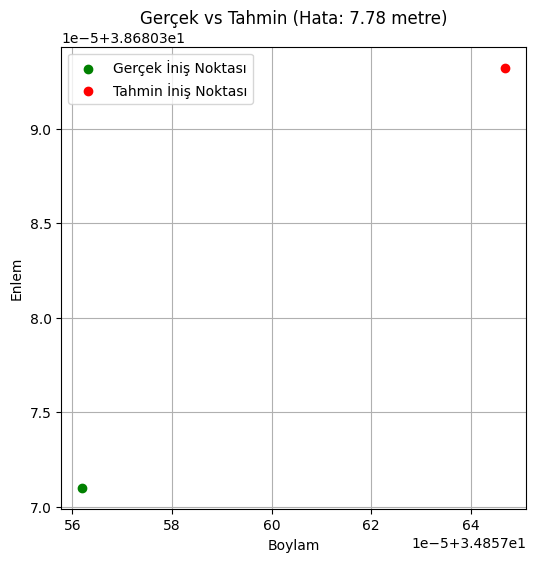

✅ Seçilen uçuşta haversine hata: 7.78 metre


In [ ]:
import matplotlib.pyplot as plt
import random

random.seed(None)


# Validation setinden rastgele bir uçuş seç
idx = random.randint(0, len(X_val_scaled) - 1)

# Gerçek ve tahmin edilen iniş noktası
y_true = y_scaler.inverse_transform(y_val_scaled)[idx]
y_pred = y_scaler.inverse_transform(model.predict(X_val_scaled[idx:idx+1]))[0]

# Haversine mesafesi
test_distance = haversine_distance(y_true[0], y_true[1], y_pred[0], y_pred[1])

# Görselleştirme
plt.figure(figsize=(6,6))
plt.scatter(y_true[1], y_true[0], color='green', label='Gerçek İniş Noktası')
plt.scatter(y_pred[1], y_pred[0], color='red', label='Tahmin İniş Noktası')
plt.title(f"Gerçek vs Tahmin (Hata: {test_distance:.2f} metre)")
plt.xlabel("Boylam")
plt.ylabel("Enlem")
plt.legend()
plt.grid(True)
plt.show()

# Ekrana yaz
print(f"✅ Seçilen uçuşta haversine hata: {test_distance:.2f} metre")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


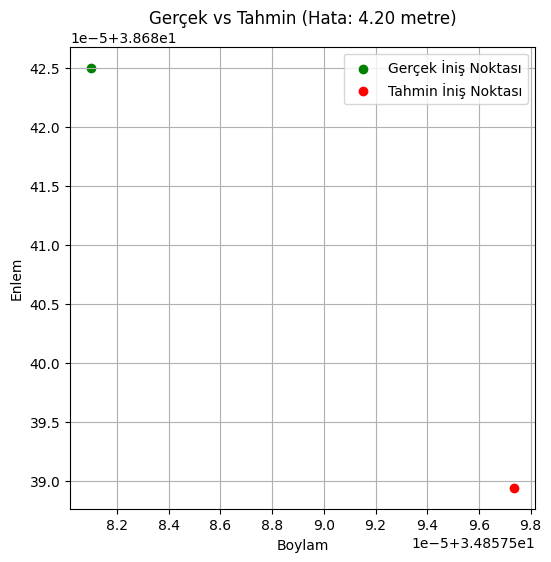

✅ Seçilen uçuşta haversine hata: 4.20 metre


In [ ]:
import matplotlib.pyplot as plt

# Manuel uçuş seç
idx = 3 # Burayı değiştirerek istediğin validation uçuşunu seçebilirsin

# Gerçek ve tahmin edilen iniş noktası
y_true = y_scaler.inverse_transform(y_val_scaled)[idx]
y_pred = y_scaler.inverse_transform(model.predict(X_val_scaled[idx:idx+1]))[0]

# Haversine mesafesi
test_distance = haversine_distance(y_true[0], y_true[1], y_pred[0], y_pred[1])

# Görselleştirme
plt.figure(figsize=(6,6))
plt.scatter(y_true[1], y_true[0], color='green', label='Gerçek İniş Noktası')
plt.scatter(y_pred[1], y_pred[0], color='red', label='Tahmin İniş Noktası')
plt.title(f"Gerçek vs Tahmin (Hata: {test_distance:.2f} metre)")
plt.xlabel("Boylam")
plt.ylabel("Enlem")
plt.legend()
plt.grid(True)
plt.show()

# Ekrana yaz
print(f"✅ Seçilen uçuşta haversine hata: {test_distance:.2f} metre")


In [ ]:
len(y_val_scaled)

13

In [ ]:
len(y_train_scaled)

51